In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_excel('iris_dataset.xlsx', sheet_name='Iris')
print("تعداد کل نمونه‌ها:", len(data))
print(data['Species'].value_counts())

تعداد کل نمونه‌ها: 150
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:

data_train, data_test = train_test_split(
    data, test_size=0.2, random_state=42, stratify=data['Species']
)


data_train.to_excel("iris_train.xlsx", index=False)
data_test.to_excel("iris_test.xlsx", index=False)  

print("Train:", len(data_train))
print("Test:", len(data_test))

Train: 120
Test: 30


In [ ]:
for species in ['setosa', 'versicolor', 'virginica']:
    subset = data_train[data_train['Species'] == species].copy()
    subset = subset.drop(columns=['Species'])  
    subset.to_csv(f"train_{species}.csv", index=False)
    print(f"train_{species}.csv → {len(subset)} نمونه")

train_setosa.csv → 40 نمونه
train_versicolor.csv → 40 نمونه
train_virginica.csv → 40 نمونه


In [5]:
from mlforkidsnumbers import MLforKidsNumbers

project = MLforKidsNumbers(
    modelurl="https://mlforkids-newnumbers.j8ayd8ayn23.eu-de.codeengine.appdomain.cloud/saved-models/auth0|6a48f728e746a2b505255257-2/status"
)


testvalue = {
    "SepalLengthC": 5.1,
    "SepalWidthCm":  3.5,
    "PetalLengthC": 1.4,
    "PetalWidthCm":  0.2,
}

response = project.classify(testvalue)
top_match = response[0]

label = top_match["class_name"]
confidence = top_match["confidence"]

print("result: '%s' with %d%% confidence" % (label, confidence))

 MLforKids : Checking for downloaded model... 
 MLforKids : Reusing downloaded model from saved_models\auth0_6a48f728e746a2b505255257-2 
 MLforKids : Loading model... 
 MLforKids : Accessing model metadata... 
 MLforKids : Model trained at 2026-09-29T16:05:33.437651 
result: 'setosa' with 96% confidence


In [7]:
data_test = pd.read_excel('iris_test.xlsx')

predictions = []
for i in range(len(data_test)):
    row = data_test.iloc[i]
    result = project.classify({
        "SepalLengthC": float(row['SepalLengthC']),
        "SepalWidthCm":  float(row['SepalWidthCm']),
        "PetalLengthC": float(row['PetalLengthC']),
        "PetalWidthCm":  float(row['PetalWidthCm']),
    })
    predictions.append(result[0]['class_name'])

data_test['Prediction'] = predictions
data_test.to_excel("iris_test_with_prediction.xlsx", index=False)
print(data_test.head(10))

   SepalLengthC  SepalWidthCm  PetalLengthC  PetalWidthCm     Species  \
0           4.4           3.0           1.3           0.2      setosa   
1           6.1           3.0           4.9           1.8   virginica   
2           4.9           2.4           3.3           1.0  versicolor   
3           5.0           2.3           3.3           1.0  versicolor   
4           4.4           3.2           1.3           0.2      setosa   
5           6.3           3.3           4.7           1.6  versicolor   
6           4.6           3.6           1.0           0.2      setosa   
7           5.4           3.4           1.7           0.2      setosa   
8           6.5           3.0           5.2           2.0   virginica   
9           5.4           3.0           4.5           1.5  versicolor   

   Prediction  
0      setosa  
1   virginica  
2  versicolor  
3  versicolor  
4      setosa  
5  versicolor  
6      setosa  
7      setosa  
8   virginica  
9  versicolor  


Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


<Axes: >

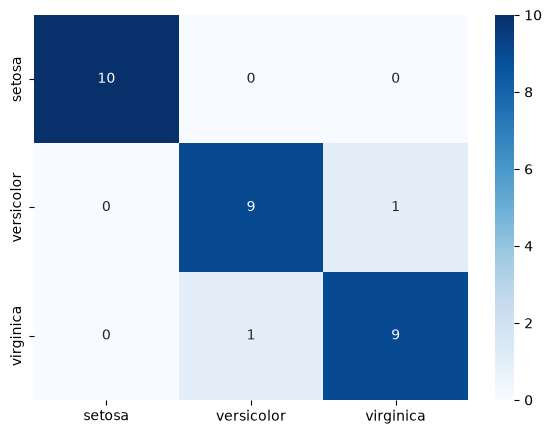

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, classification_report

labels = ['setosa', 'versicolor', 'virginica']
truth = data_test['Species']
preds = data_test['Prediction']

cm = confusion_matrix(truth, preds, labels=labels)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)



In [17]:

from sklearn.metrics import classification_report

print(classification_report(truth,predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

